<a href="https://colab.research.google.com/github/elizaabethnguyen/deepfake-detection/blob/main/deepfake_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/img_align_celeba.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/celeba')

print("Extraction complete")

Extraction complete


In [ ]:
import os

print(os.listdir('/content/celeba')[:5])

['img_align_celeba']


In [ ]:
import torchvision.datasets as dset
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

dataset = dset.ImageFolder(
    root='/content/celeba',
    transform=transform
)

print("Dataset size:", len(dataset))

Dataset size: 202599


In [ ]:
from torch.utils.data import Subset

subset_indices = list(range(5000))

dataset = Subset(dataset, subset_indices)

print("Subset size:", len(dataset))

Subset size: 5000


In [ ]:
import torch

BATCH_SIZE = 64

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

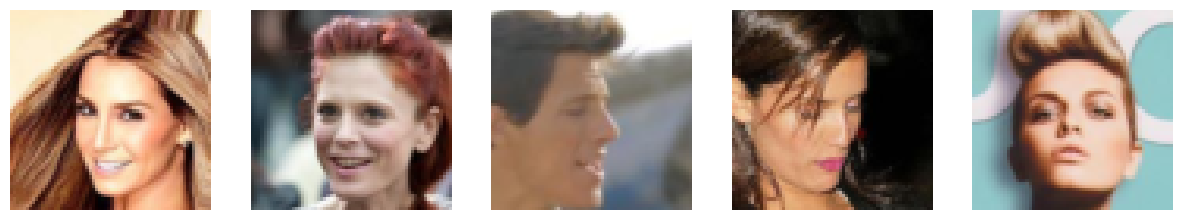

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,5, figsize=(15,5))

for i in range(5):
    img, _ = dataset[i]

    img = img.permute(1,2,0)
    img = (img + 1) / 2

    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()